# Analyse des retards de livraison

**Projet Data Science — Semaine 17 · Groupe 4**

**Objectif :** Identifier les facteurs explicatifs des délais de livraison et quantifier les leviers d'action opérationnels.

**Données :** *Food Delivery Dataset* (Kaggle), 45 593 livraisons urbaines (février-avril 2022).

## Sommaire

| Partie | Tâches | Contenu
|---|---|---
| A - Préparer les données | 1 à 4 | Chargement, nettoyage, variables, seuil de retard
| B - Analyser par axe | 5 à 9 | Temps, Espace, Conditions, Véhicule, Coût
| C - Croiser et comparer | 10 à 12 | Corrélations, comparaisons, tableau de bord
| D - Conclure | 13 à 16 | Scénarios, règles d'interprétation, bilan

## 0. Initialisation

Configuration de l'environnement, des chemins d'accès et des paramètres d'affichage graphique.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter  # separate les milliers
from matplotlib.patches import Patch  # carres de couleur pour la legende

# Localisation dynamique de la racine du projet
dossier = Path.cwd()
while (
    dossier != dossier.parent and not (dossier / "data" / "raw" / "train.csv").exists()
):
    dossier = dossier.parent

FICHIER_DONNEES = dossier / "data" / "raw" / "train.csv"
DOSSIER_FIGURES = dossier / "figures"
DOSSIER_TABLES = dossier / "outputs" / "tables"
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)
DOSSIER_TABLES.mkdir(parents=True, exist_ok=True)

# --- Affichage -------------------------------------------------------------
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.titlesize"] = 13

SEUIL_MIN_LIVRAISONS = 100  # règle de fiabilité fixée avant l'analyse (KPI K12)


## Tâche 1 — Ingestion et audit structurel

Chargement des données brutes (20 variables, 45 593 observations) et audit initial des types et anomalies.

In [2]:
df = pd.read_csv(FICHIER_DONNEES)

# Profil du fichier brut : types, valeurs manquantes, nombre de modalités.
profil_brut = pd.DataFrame(
    {
        "type": df.dtypes,
        "modalites": df.nunique(),
        "exemple": [
            df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns
        ],
    }
)
profil_brut.index.name = "colonne"
profil_brut

,type,modalites,exemple
colonne,,,
ID,str,45593,0x4607
Delivery_person_ID,str,1320,INDORES13DEL02
Delivery_person_Age,str,23,37
Delivery_person_Ratings,str,29,4.9
Restaurant_latitude,float64,657,22.745049
Restaurant_longitude,float64,518,75.892471
Delivery_location_latitude,float64,4373,22.765049
Delivery_location_longitude,float64,4373,75.912471
Order_Date,str,44,19-03-2022


## Tâche 2 — Nettoyage et fiabilisation

- Suppression des espaces parasites et conversion des `NaN` textuels en `pd.NA`.
- Typage numérique (`duree`, coordonnées, âge, note).
- Filtrage des coordonnées GPS aberrantes (point zéro) et durées non plausibles.
- Imputation par `Inconnu` pour les variables catégorielles incomplètes.

In [3]:
donnees = df.copy()
lignes_depart = len(donnees)
journal = []

# --- Correction 1 : espaces parasites autour des textes --------------------
colonnes_texte = [
    "ID",
    "Delivery_person_ID",
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Time_Orderd",
    "Time_Order_picked",
    "Order_Date",
    "Time_taken(min)",
]

for colonne in colonnes_texte:
    donnees[colonne] = donnees[colonne].astype("string").str.strip()

# Correction 2 : conversion des 'NaN' textuels en valeurs manquantes pd.NA
for colonne in colonnes_texte:
    donnees[colonne] = donnees[colonne].replace(
        {"NaN": pd.NA, "nan": pd.NA, "None": pd.NA, "": pd.NA}
    )

donnees["Weatherconditions"] = (
    donnees["Weatherconditions"].str.replace("(?i)nan", "", regex=True).str.strip()
)
donnees.loc[donnees["Weatherconditions"] == "conditions", "Weatherconditions"] = pd.NA

# --- Correction 3 : types numériques --------------------------------------
donnees["duree"] = (
    donnees["Time_taken(min)"].str.replace(r"\(min\)", "", regex=True).astype(float)
)

for colonne in [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "multiple_deliveries",
]:
    donnees[colonne] = pd.to_numeric(donnees[colonne], errors="coerce")

donnees["etat_vehicule"] = pd.to_numeric(
    donnees["Vehicle_condition"].astype("string").str.strip(), errors="coerce"
)

donnees.dtypes.head(22).to_frame("type")

,type
colonne,
ID,string
Delivery_person_ID,string
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,string


In [4]:
# --- Filtres : doublons, coordonnées, durées ------------------------------
avant = len(donnees)
donnees = donnees.drop_duplicates(subset=["ID"], keep="first")
journal.append(
    ("Doublons d'identifiant", avant - len(donnees), "Un identifiant = une livraison")
)

avant = len(donnees)
bornes = (
    donnees["Restaurant_latitude"].between(5, 36)
    & donnees["Restaurant_longitude"].between(68, 98)
    & donnees["Delivery_location_latitude"].between(5, 36)
    & donnees["Delivery_location_longitude"].between(68, 98)
)
donnees = donnees[bornes].copy()
journal.append(
    (
        "Coordonnées hors du territoire",
        avant - len(donnees),
        "Coordonnées GPS aberrantes (0, 0)",
    )
)

avant = len(donnees)
donnees = donnees[donnees["duree"].between(1, 200)].copy()
journal.append(
    (
        "Durées impossibles ou manquantes",
        avant - len(donnees),
        "Bornes de plausibilité : 1 à 200 minutes",
    )
)

# --- Complétions plutôt que suppression -------------------------------------
for colonne in ["Weatherconditions", "Road_traffic_density", "City", "Type_of_vehicle"]:
    donnees[colonne] = donnees[colonne].fillna("Inconnu")

taux_conservation = 100 * len(donnees) / lignes_depart
pd.DataFrame(journal, columns=["opération", "lignes retirées", "motif"])

,opération,lignes retirées,motif
0,Doublons d'identifiant,0,Un identifiant = une livraison
1,Coordonnées hors du territoire,4071,"Coordonnées GPS aberrantes (0, 0)"
2,Durées impossibles ou manquantes,0,Bornes de plausibilité : 1 à 200 minutes


In [5]:
# --- Bilan du nettoyage ---------------------------------------------------
# Après correction, le tableau compte 20 colonnes d'origine + "duree" et
# "etat_vehicule" créés en tâche 2, soit 22 colonnes au total.
pd.DataFrame(
    {
        "indicateur": [
            "Lignes lues",
            "Lignes analysées",
            "Lignes retirées",
            "Taux de conservation",
            "Colonnes",
        ],
        "valeur": [
            f"{lignes_depart:,}",
            f"{len(donnees):,}",
            f"{lignes_depart - len(donnees):,}",
            f"{taux_conservation:.2f} %",
            donnees.shape[1],
        ],
    }
).set_index("indicateur").T

indicateur,Lignes lues,Lignes analysées,Lignes retirées,Taux de conservation,Colonnes
valeur,"45,593","41,522","4,071",91.07 %,22


## Tâche 3 — Feature Engineering

- **Distance (km) :** formule de Haversine vectorisée.
- **Attente restaurant (min) :** délai commande-ramassage avec correction du franchissement de minuit (+24h).
- **Variables temporelles :** heure, jour, indicateur heure de pointe, tranches horaires et classes de distance.

In [6]:
RAYON_TERRE_KM = 6371.0


def distance_haversine(lat1, lon1, lat2, lon2):
    """Distance en kilometres entre deux points du globe (formule de Haversine)."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )
    return 2 * RAYON_TERRE_KM * np.arcsin(np.sqrt(a))


donnees["distance_km"] = distance_haversine(
    donnees["Restaurant_latitude"],
    donnees["Restaurant_longitude"],
    donnees["Delivery_location_latitude"],
    donnees["Delivery_location_longitude"],
)

# Verification de la formule sur deux distances connues
pd.DataFrame(
    {
        "trajet": ["Paris-Londres", "Bogota-Medellin"],
        "calcule (km)": [
            round(distance_haversine(48.8566, 2.3522, 51.5074, -0.1278), 1),
            round(distance_haversine(4.7110, -74.0721, 6.2442, -75.5812), 1),
        ],
        "reel (km)": [344, 239],
    }
)

,trajet,calcule (km),reel (km)
0,Paris-Londres,343.6,344
1,Bogota-Medellin,238.7,239


In [7]:
# Contrôle des horodatages illisibles (errors='coerce')
controle_parsing = pd.DataFrame(
    [
        {
            "colonne": colonne,
            "valeurs illisibles": int(
                pd.to_datetime(donnees[colonne], format="%H:%M:%S", errors="coerce")
                .isna()
                .sum()
            ),
            "part (%)": round(
                100
                * pd.to_datetime(donnees[colonne], format="%H:%M:%S", errors="coerce")
                .isna()
                .mean(),
                2,
            ),
        }
        for colonne in ["Time_Orderd", "Time_Order_picked"]
    ]
)
controle_parsing["interpretation"] = [
    "horodatage absent du fichier, non lisible" if p < 1 else "a verifier"
    for p in controle_parsing["part (%)"]
]
controle_parsing

# --- Fusion de la date et de l'heure en un seul datetime64 ----------------
# Le fichier donne l'heure de commande et l'heure de ramassage, mais la date
# de ramassage reste inconnue : on ancre les deux sur la date de commande.
FORMAT_HORODATAGE = "%d-%m-%Y %H:%M:%S"
donnees["datetime_commande"] = pd.to_datetime(
    donnees["Order_Date"].astype("string")
    + " "
    + donnees["Time_Orderd"].astype("string"),
    format=FORMAT_HORODATAGE,
    errors="coerce",
)
donnees["datetime_ramassage"] = pd.to_datetime(
    donnees["Order_Date"].astype("string")
    + " "
    + donnees["Time_Order_picked"].astype("string"),
    format=FORMAT_HORODATAGE,
    errors="coerce",
)

donnees["attente_min"] = (
    donnees["datetime_ramassage"] - donnees["datetime_commande"]
).dt.total_seconds() / 60

# Correction du franchissement de minuit (+24h si écart négatif)
n_negatifs = int((donnees["attente_min"] < 0).sum())
donnees.loc[donnees["attente_min"] < 0, "attente_min"] += 24 * 60

heure_commande = donnees["datetime_commande"]
donnees["date"] = donnees["datetime_commande"].dt.normalize()

pd.DataFrame(
    {
        "controle": [
            "Ecarts negatifs avant correction",
            "Attente > 90 min apres correction",
            "Attente : valeur mediane",
            "Attente : valeur maximale",
        ],
        "valeur": [
            n_negatifs,
            int((donnees["attente_min"] > 90).sum()),
            f"{donnees['attente_min'].median():.1f} min",
            f"{donnees['attente_min'].max():.1f} min",
        ],
    }
).set_index("controle").T

controle,Ecarts negatifs avant correction,Attente > 90 min apres correction,Attente : valeur mediane,Attente : valeur maximale
valeur,760,0,10.0 min,15.0 min


In [8]:
donnees["heure"] = heure_commande.dt.hour
donnees["jour"] = donnees["date"].dt.dayofweek
donnees["jour_nom"] = donnees["jour"].map(
    dict(
        enumerate(
            ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
        )
    )
)
donnees["est_weekend"] = donnees["jour"] >= 5

HEURES_POINTE = [8, 9, 18, 19, 20]
donnees["est_pointe"] = donnees["heure"].isin(HEURES_POINTE)

donnees["tranche"] = pd.cut(
    donnees["heure"],
    bins=[0, 6, 11, 15, 18, 23],
    labels=["Nuit", "Matin", "Midi", "Apres-midi", "Soir"],
    right=False,
    include_lowest=True,
)

donnees["classe_distance"] = pd.cut(
    donnees["distance_km"],
    bins=[0, 2, 5, 10, 20, 100],
    labels=["< 2 km", "2-5 km", "5-10 km", "10-20 km", "> 20 km"],
    right=False,
    include_lowest=True,
)

In [9]:
# Noms de catégories simplifiés et niveaux ordinaux (utilisés en tâche 10)
donnees["meteo"] = donnees["Weatherconditions"].str.replace(
    "conditions ", "", regex=False
)
donnees["ville"] = donnees["City"].map(
    {
        "Metropolitian": "Metropolitaine",
        "Semi-Urban": "Semi-urbaine",
        "Urban": "Urbaine",
        "Inconnu": "Inconnu",
    }
)
donnees["vehicule"] = donnees["Type_of_vehicle"].str.replace("_", " ")
# Encodage ordinal de convenance pour la matrice de corrélation (V10).
# L'ordre du trafic (Low < Medium < High < Jam) est naturel ; l'ordre de la
# météo (Sunny < ... < Sandstorms) est une hypothèse discutable : Sandstorms >
# Stormy n'est pas une évidence. Ces codages ne servent qu'aux corrélations ;
# les comparaisons de groupes utilisent les catégories brutes.
donnees["niveau_trafic"] = donnees["Road_traffic_density"].map(
    {"Low": 1, "Medium": 2, "High": 3, "Jam": 4, "Inconnu": 0}
)
donnees["niveau_meteo"] = donnees["meteo"].map(
    {
        "Sunny": 1,
        "Windy": 2,
        "Cloudy": 3,
        "Fog": 4,
        "Stormy": 5,
        "Sandstorms": 6,
        "Inconnu": 0,
    }
)
donnees["age_livreur"] = pd.to_numeric(donnees["Delivery_person_Age"], errors="coerce")
donnees["note_livreur"] = pd.to_numeric(
    donnees["Delivery_person_Ratings"], errors="coerce"
)

donnees[
    [
        "duree",
        "distance_km",
        "attente_min",
        "heure",
        "tranche",
        "meteo",
        "ville",
        "vehicule",
    ]
].head()

colonne,duree,distance_km,attente_min,heure,tranche,meteo,ville,vehicule
0,24.0,3.025149,15.0,11.0,Midi,Sunny,Urbaine,motorcycle
1,33.0,20.183530,5.0,19.0,Soir,Stormy,Metropolitaine,scooter
2,26.0,1.552758,15.0,8.0,Matin,Sandstorms,Urbaine,motorcycle
3,21.0,7.790401,10.0,18.0,Soir,Sunny,Metropolitaine,motorcycle
4,30.0,6.210138,15.0,13.0,Midi,Cloudy,Metropolitaine,scooter


## Tâche 4 — Définition du retard et valorisation financière

- **Seuil de retard :** médiane observée (26,0 min) avec analyse de sensibilité (75e percentile et seuil fixe 40 min).
- **Minutes perdues :** `max(0, duree - 26 min)`.
- **Coût du retard :** **hypothèse illustrative** sans source externe, scénario central à 1 200 / heure (sensibilité testée à 500 et 2 500 / h).

In [10]:
SEUIL_RETARD = donnees["duree"].median()
donnees["en_retard"] = (donnees["duree"] > SEUIL_RETARD).astype(int)
donnees["minutes_perdues"] = (donnees["duree"] - SEUIL_RETARD).clip(lower=0)

# Barème conventionnel et illustratif : le jeu de données ne contient aucun
# montant. Ces valeurs (devise locale / heure) ne servent qu'à comparer trois
# ordres de grandeur ; l'analyse de sensibilité du barème montre que le classement
# des facteurs ne dépend pas du barème retenu.
PRIX_HORAIRE = {"bas": 500, "central": 1200, "haut": 2500}
SCENARIO_REFERENCE = "central"
donnees["cout_par_minute"] = PRIX_HORAIRE[SCENARIO_REFERENCE] / 60
donnees["cout_retard"] = donnees["minutes_perdues"] * donnees["cout_par_minute"]

minutes_total = donnees["minutes_perdues"].sum()

pd.DataFrame(
    {
        "paramètre": [
            "Seuil de retard",
            "Taux de retard",
            "Minutes perdues / livraison",
            "Minutes perdues au total",
        ],
        "valeur": [
            f"{SEUIL_RETARD:.1f} min",
            f"{100 * donnees['en_retard'].mean():.2f} %",
            f"{donnees['minutes_perdues'].mean():.2f} min",
            f"{minutes_total:,.0f} min",
        ],
    }
).set_index("paramètre").T

paramètre,Seuil de retard,Taux de retard,Minutes perdues / livraison,Minutes perdues au total
valeur,26.0 min,45.57 %,3.94 min,"163,579 min"


In [11]:
# Sensibilité au seuil : les chiffres changent, mais le classement des
# facteurs reste identique.
pd.DataFrame(
    [
        {
            "définition du seuil": libelle,
            "seuil (min)": round(seuil, 1),
            "taux de retard (%)": round(100 * (donnees["duree"] > seuil).mean(), 2),
            "minutes perdues": int((donnees["duree"] - seuil).clip(lower=0).sum()),
        }
        for libelle, seuil in [
            ("Médiane (retenu)", donnees["duree"].median()),
            ("Percentile 75", donnees["duree"].quantile(0.75)),
            ("Seuil fixe", 40.0),
        ]
    ]
)

,définition du seuil,seuil (min),taux de retard (%),minutes perdues
0,Médiane (retenu),26.0,45.57,163579
1,Percentile 75,32.0,24.81,74878
2,Seuil fixe,40.0,8.86,18636


In [12]:
# Sensibilité au prix horaire : le montant change d'échelle, pas le classement.
pd.DataFrame(
    [
        {
            "scénario de prix": nom,
            "prix horaire": prix,
            "coût total des retards": round(minutes_total / 60 * prix),
        }
        for nom, prix in PRIX_HORAIRE.items()
    ]
)

,scénario de prix,prix horaire,coût total des retards
0,bas,500,1363158
1,central,1200,3271580
2,haut,2500,6815792


---
# Partie B — Analyses univariées et bivariées (tâches 5 à 9)

## Tâche 5 — Axe Temporel : horaires et jours de la semaine

Analyse des délais selon les tranches horaires, les jours de la semaine (du lundi au dimanche), les heures de pointe et le week-end.

In [13]:
ORDRE_TRANCHES = ["Nuit", "Matin", "Midi", "Apres-midi", "Soir"]


def par_categorie(colonne, ordre=None, cible="duree"):
    """Synthèse par catégorie : effectif, durée moyenne, taux de retard."""
    synthese = (
        donnees.groupby(colonne, observed=True)
        .agg(
            nombre=(cible, "count"),
            duree_moyenne=(cible, "mean"),
            duree_mediane=(cible, "median"),
            taux_retard=("en_retard", lambda x: 100 * x.mean()),
            minutes_perdues=("minutes_perdues", "mean"),
        )
        .round(2)
    )
    if ordre is not None:
        synthese = synthese.reindex([o for o in ordre if o in synthese.index])
    return synthese


par_tranche = par_categorie("tranche", ORDRE_TRANCHES)
par_tranche

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
tranche,,,,,
Nuit,395,21.97,21.0,25.57,1.34
Matin,5272,19.56,19.0,13.35,0.38
Midi,4056,26.87,27.0,52.37,3.75
Apres-midi,5377,26.29,26.0,48.73,3.55
Soir,20991,28.75,28.0,55.80,5.47


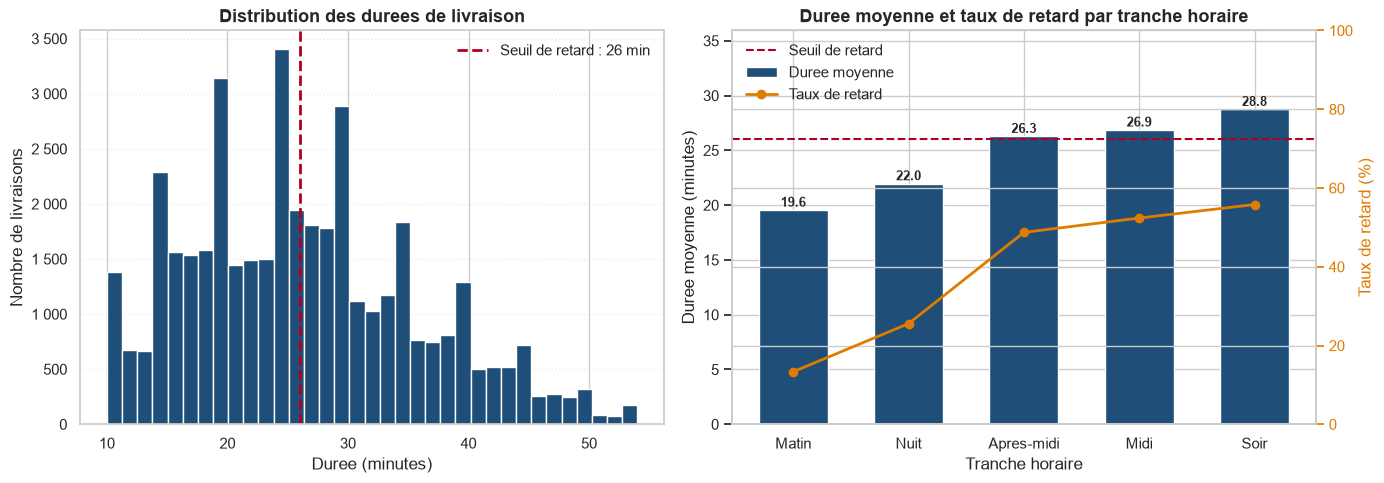

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panneau 1 : distribution des durees -------------------------------
axes[0].hist(donnees["duree"], bins=35, color="#1f4e79", edgecolor="white")
axes[0].axvline(
    SEUIL_RETARD,
    color="#b00020",
    linestyle="--",
    linewidth=2,
    label=f"Seuil de retard : {SEUIL_RETARD:.0f} min",
)
axes[0].set_title("Distribution des durees de livraison", fontweight="bold")
axes[0].set_xlabel("Duree (minutes)")
axes[0].set_ylabel("Nombre de livraisons")
# 40 000 se lit mieux que 40000
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
axes[0].grid(axis="y", linestyle=":", alpha=0.4)
axes[0].legend(frameon=False)

# --- Panneau 2 : duree moyenne ET taux de retard par tranche horaire ---
donnees_graphique = par_tranche.sort_values("duree_moyenne")
positions = list(range(len(donnees_graphique)))

barres = axes[1].bar(
    positions,
    donnees_graphique["duree_moyenne"],
    width=0.6,
    color="#1f4e79",
    label="Duree moyenne",
)
for barre, valeur in zip(barres, donnees_graphique["duree_moyenne"]):
    axes[1].text(
        barre.get_x() + barre.get_width() / 2,
        barre.get_height() + 0.3,
        f"{valeur:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# Le taux de retard n est pas dans la meme unite : deuxieme axe vertical.
axe_taux = axes[1].twinx()
axe_taux.plot(
    positions,
    donnees_graphique["taux_retard"],
    color="#e07b00",
    marker="o",
    linewidth=2,
    label="Taux de retard",
)
axe_taux.set_ylabel("Taux de retard (%)", color="#e07b00")
axe_taux.tick_params(axis="y", colors="#e07b00")
axe_taux.set_ylim(0, 100)

axes[1].axhline(
    SEUIL_RETARD,
    color="#b00020",
    linestyle="--",
    linewidth=1.5,
    label="Seuil de retard",
)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(donnees_graphique.index)
axes[1].set_title("Duree moyenne et taux de retard par tranche horaire", fontweight="bold")
axes[1].set_xlabel("Tranche horaire")
axes[1].set_ylabel("Duree moyenne (minutes)")
axes[1].set_ylim(0, donnees_graphique["duree_moyenne"].max() * 1.25)

# Legende combinee des deux axes
mots, valeurs = [], []
for axe in (axes[1], axe_taux):
    g, t = axe.get_legend_handles_labels()
    mots, valeurs = mots + g, valeurs + t
axes[1].legend(mots, valeurs, frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V1_V2_distribution_et_tranches.png", dpi=110)
plt.show()

In [15]:
# Synthèse par jour de la semaine (Lundi à Dimanche)
ORDRE_JOURS = [
    "Lundi",
    "Mardi",
    "Mercredi",
    "Jeudi",
    "Vendredi",
    "Samedi",
    "Dimanche",
]
par_jour = par_categorie("jour_nom", ORDRE_JOURS)
par_jour

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
jour_nom,,,,,
Lundi,5490,26.24,25.0,44.72,3.88
Mardi,5612,25.45,25.0,42.57,3.39
Mercredi,6285,27.76,27.0,50.93,4.85
Jeudi,5607,25.31,25.0,41.82,3.28
Vendredi,6125,26.83,26.0,47.80,4.27
Samedi,5575,26.00,25.0,44.61,3.75
Dimanche,5503,26.43,25.0,45.54,4.01


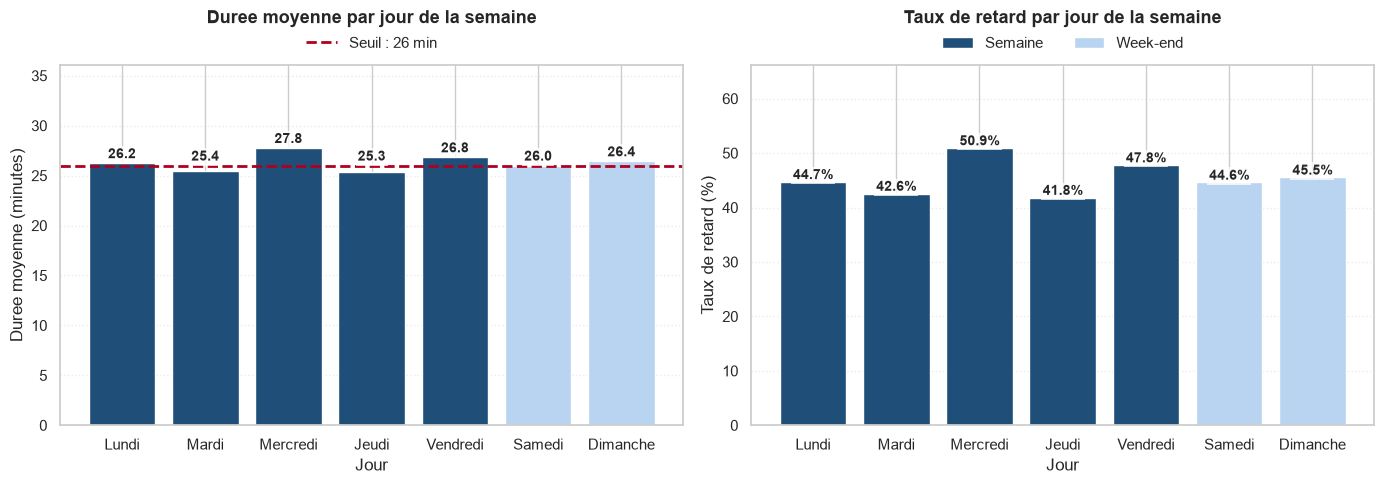

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekend en bleu clair, semaine en bleu fonce
couleurs = [
    "#b8d4f0" if j in ("Samedi", "Dimanche") else "#1f4e79"
    for j in par_jour.index
]

# Espace reserve au-dessus des barres. Sans cette marge, les etiquettes des
# plus hautes barres sortent du cadre et sont coupees.
MARGE_HAUT = 1.30


def poser_etiquettes(axe, barres, valeurs, suffixe="", ligne_reference=0):
    """Ecrit la valeur au-dessus de chaque barre, sans etre masquee.

    ligne_reference : hauteur d un eventuel trait horizontal. L etiquette
    est alors posee au-dessus du trait, sinon le nombre se retrouve
    barre par la ligne pointillee et devient illisible.
    """
    for barre, valeur in zip(barres, valeurs):
        haut = max(barre.get_height(), ligne_reference)
        axe.text(
            barre.get_x() + barre.get_width() / 2,
            haut + 0.5,
            f"{valeur:.1f}{suffixe}",
            ha="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5, alpha=0.75),
        )


def cadre_lisible(axe, titre, legende=None):
    """Habillage commun : titre en gras, grille, legende au-dessus du cadre.

    La legende sort du cadre pour ne plus recouvrir les barres. Le titre est
    remonte (pad) pour lui laisser la place.
    """
    if legende is None:
        axe.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=1)
    else:
        axe.legend(handles=legende, frameon=False, loc="lower center",
                   bbox_to_anchor=(0.5, 1.0), ncol=2)
    axe.set_title(titre, fontweight="bold", pad=30)
    axe.set_xlabel("Jour")
    axe.grid(axis="y", linestyle=":", alpha=0.4)
    axe.set_axisbelow(True)


# --- Panneau 1 : duree moyenne par jour --------------------------------
barres = axes[0].bar(par_jour.index, par_jour["duree_moyenne"], color=couleurs)
axes[0].axhline(SEUIL_RETARD, color="#b00020", linestyle="--", linewidth=2,
                label=f"Seuil : {SEUIL_RETARD:.0f} min")

poser_etiquettes(axes[0], barres, par_jour["duree_moyenne"], ligne_reference=SEUIL_RETARD)
axes[0].set_ylim(0, max(par_jour["duree_moyenne"].max(), SEUIL_RETARD) * MARGE_HAUT)
axes[0].set_ylabel("Duree moyenne (minutes)")
cadre_lisible(axes[0], "Duree moyenne par jour de la semaine")

# --- Panneau 2 : taux de retard par jour ------------------------------
barres2 = axes[1].bar(par_jour.index, par_jour["taux_retard"], color=couleurs)

poser_etiquettes(axes[1], barres2, par_jour["taux_retard"], suffixe="%")
axes[1].set_ylim(0, par_jour["taux_retard"].max() * MARGE_HAUT)
axes[1].set_ylabel("Taux de retard (%)")

# Legende manuelle : semaine / week-end
elements_semaine = [
    Patch(facecolor="#1f4e79", label="Semaine"),
    Patch(facecolor="#b8d4f0", label="Week-end"),
]
cadre_lisible(axes[1], "Taux de retard par jour de la semaine", legende=elements_semaine)

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V3_jours_semaine.png", dpi=110)
plt.show()

In [17]:
# Test de l'hypothèse H3 : les heures de pointe concentrent-elles les retards ?
pointe = donnees.loc[donnees["est_pointe"], "duree"]
autres = donnees.loc[~donnees["est_pointe"], "duree"]
test_pointe = stats.mannwhitneyu(pointe, autres, alternative="two-sided")

# Comparaison avec / sans heures de pointe, et avec / sans week-end
pd.DataFrame(
    [
        {
            "comparaison": g,
            "durée moyenne (min)": round(x, 2),
            "taux de retard (%)": round(100 * donnees.loc[m, "en_retard"].mean(), 2),
        }
        for g, x, m in [
            ("Heures de pointe", pointe.mean(), donnees["est_pointe"]),
            ("Autres heures", autres.mean(), ~donnees["est_pointe"]),
            (
                "Jour de semaine",
                donnees.loc[~donnees["est_weekend"], "duree"].mean(),
                ~donnees["est_weekend"],
            ),
            (
                "Week-end",
                donnees.loc[donnees["est_weekend"], "duree"].mean(),
                donnees["est_weekend"],
            ),
        ]
    ]
).set_index("comparaison").T

comparaison,Heures de pointe,Autres heures,Jour de semaine,Week-end
durée moyenne (min),27.58,25.52,26.35,26.21
taux de retard (%),50.96,42.20,45.75,45.07


## Tâche 6 — Axe Spatial : distance kilométrique et zones critiques

In [18]:
correlation_distance = donnees["distance_km"].corr(donnees["duree"])
pente = np.polyfit(donnees["distance_km"], donnees["duree"], 1)[0]

par_distance = par_categorie(
    "classe_distance", ["< 2 km", "2-5 km", "5-10 km", "10-20 km", "> 20 km"]
)
par_ville = par_categorie("ville")

pd.DataFrame(
    {
        "indicateur": [
            "Corrélation distance / durée",
            "Minutes ajoutées par km (K9)",
            "Distance médiane",
            "Durée médiane",
        ],
        "valeur": [
            f"{correlation_distance:.3f}",
            f"{pente:.3f} min/km",
            f"{donnees['distance_km'].median():.2f} km",
            f"{donnees['duree'].median():.2f} min",
        ],
    }
).set_index("indicateur").T

indicateur,Corrélation distance / durée,Minutes ajoutées par km (K9),Distance médiane,Durée médiane
valeur,0.321,0.538 min/km,9.19 km,26.00 min


In [19]:
# Le tableau par ville fait apparaître un groupe très petit : le KPI K12
# impose de contrôler les effectifs avant de conclure.
par_ville.assign(
    conclusion_possible=par_ville["nombre"] >= SEUIL_MIN_LIVRAISONS
).sort_values("duree_moyenne")

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues,conclusion_possible
ville,,,,,,
Inconnu,1097,22.11,21.0,27.89,1.94,True
Urbaine,9175,23.03,22.0,31.65,2.43,True
Metropolitaine,31103,27.32,27.0,50.04,4.36,True
Semi-urbaine,147,49.68,49.0,100.00,23.68,True


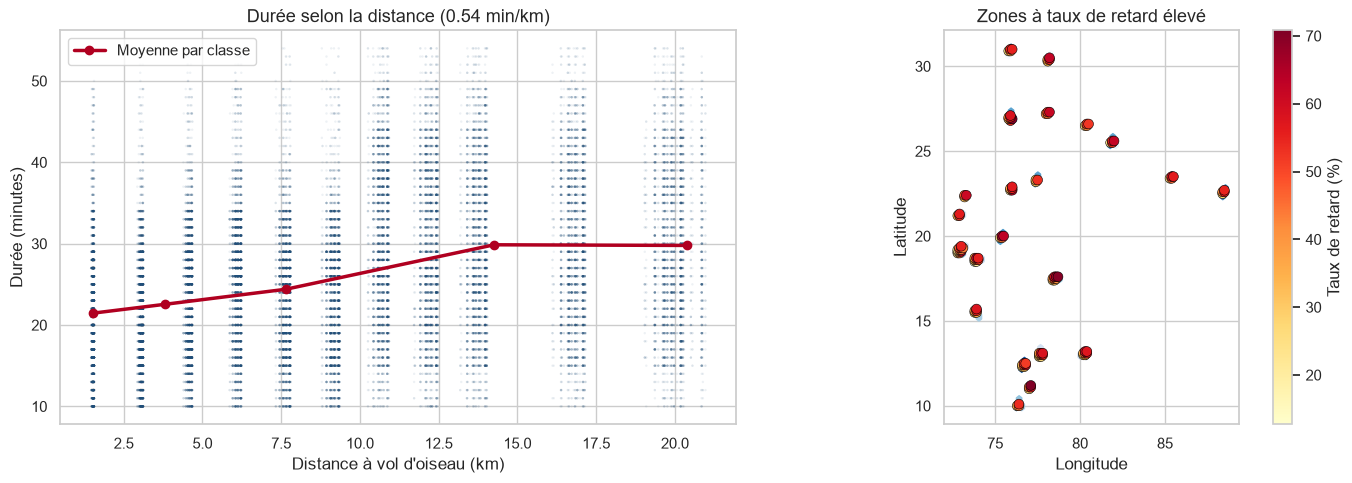

In [20]:
moyennes_classe = (
    donnees.groupby("classe_distance", observed=True)
    .agg(distance=("distance_km", "mean"), duree=("duree", "mean"))
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance et durée
axes[0].scatter(
    donnees["distance_km"],
    donnees["duree"],
    s=3,
    alpha=0.08,
    color="#1f4e79",
    edgecolors="none",
)
axes[0].plot(
    moyennes_classe["distance"],
    moyennes_classe["duree"],
    "o-",
    color="#b00020",
    linewidth=2.5,
    label="Moyenne par classe",
)
axes[0].set_title(f"Durée selon la distance ({pente:.2f} min/km)")
axes[0].set_xlabel("Distance à vol d'oiseau (km)")
axes[0].set_ylabel("Durée (minutes)")
axes[0].legend()

# Zones à retard élevé, sur grille géographique
donnees_carte = donnees.copy()
donnees_carte["case_lat"] = donnees_carte["Delivery_location_latitude"].round(1)
donnees_carte["case_lon"] = donnees_carte["Delivery_location_longitude"].round(1)
zones = (
    donnees_carte.groupby(["case_lat", "case_lon"], observed=True)
    .agg(nombre=("duree", "count"), taux_retard=("en_retard", lambda x: 100 * x.mean()))
    .round(2)
)
zones = zones[zones["nombre"] >= 30]

echantillon = donnees.sample(min(20000, len(donnees)), random_state=1)
axes[1].hexbin(
    echantillon["Delivery_location_longitude"],
    echantillon["Delivery_location_latitude"],
    gridsize=50,
    cmap="Blues",
    mincnt=1,
    bins="log",
)
scatter = axes[1].scatter(
    zones.index.get_level_values("case_lon"),
    zones.index.get_level_values("case_lat"),
    s=50,
    c=zones["taux_retard"],
    cmap="YlOrRd",
    edgecolors="black",
    linewidths=0.4,
)
axes[1].set_title("Zones à taux de retard élevé")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal")
plt.colorbar(scatter, ax=axes[1], label="Taux de retard (%)")

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V7_V9_distance_et_zones.png", dpi=110)
plt.show()

## Tâche 7 — Axe Conditions : trafic et météo

In [21]:
ORDRE_TRAFIC = ["Low", "Medium", "High", "Jam", "Inconnu"]
par_trafic = par_categorie("Road_traffic_density", ORDRE_TRAFIC)
par_trafic

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
Road_traffic_density,,,,,
Low,14095,21.28,20.0,20.81,1.10
Medium,10023,26.74,27.0,50.20,3.85
High,4046,27.21,27.0,54.13,3.91
Jam,12950,31.19,31.0,66.19,7.11
Inconnu,408,26.34,26.0,47.55,4.01


In [22]:
# Regroupement de la météo en deux familles (sinon six catégories difficiles à comparer)
donnees["meteo_groupe"] = "Neutre"
donnees.loc[donnees["meteo"].isin(["Sunny", "Windy"]), "meteo_groupe"] = "Favorable"
donnees.loc[donnees["meteo"].isin(["Fog", "Stormy", "Sandstorms"]), "meteo_groupe"] = (
    "Severe"
)

par_meteo = par_categorie("meteo_groupe", ["Favorable", "Neutre", "Severe"])
par_meteo

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
meteo_groupe,,,,,
Favorable,13474,24.03,23.0,34.57,2.64
Neutre,7301,28.79,28.0,56.66,5.70
Severe,20747,26.93,26.0,48.81,4.17


In [23]:
bas = donnees.loc[donnees["Road_traffic_density"] == "Low", "duree"]
bouche = donnees.loc[donnees["Road_traffic_density"] == "Jam", "duree"]
fav = donnees.loc[donnees["meteo_groupe"] == "Favorable", "duree"]
sev = donnees.loc[donnees["meteo_groupe"] == "Severe", "duree"]

ecart_trafic = bouche.mean() - bas.mean()
ecart_meteo = sev.mean() - fav.mean()
p_trafic = stats.mannwhitneyu(bouche, bas, alternative="two-sided").pvalue
p_meteo = stats.mannwhitneyu(sev, fav, alternative="two-sided").pvalue

pd.DataFrame(
    [
        {
            "facteur": "Trafic (fluide vs embouteillé)",
            "durée A": round(bas.mean(), 2),
            "durée B": round(bouche.mean(), 2),
            "écart (min)": round(ecart_trafic, 2),
            "p-value": f"{p_trafic:.1e}",
        },
        {
            "facteur": "Météo (favorable vs sévère)",
            "durée A": round(fav.mean(), 2),
            "durée B": round(sev.mean(), 2),
            "écart (min)": round(ecart_meteo, 2),
            "p-value": f"{p_meteo:.1e}",
        },
    ]
).set_index("facteur")

,durée A,durée B,écart (min),p-value
facteur,,,,
Trafic (fluide vs embouteillé),21.28,31.19,9.91,0.0e+00
Météo (favorable vs sévère),24.03,26.93,2.89,1.2e-193


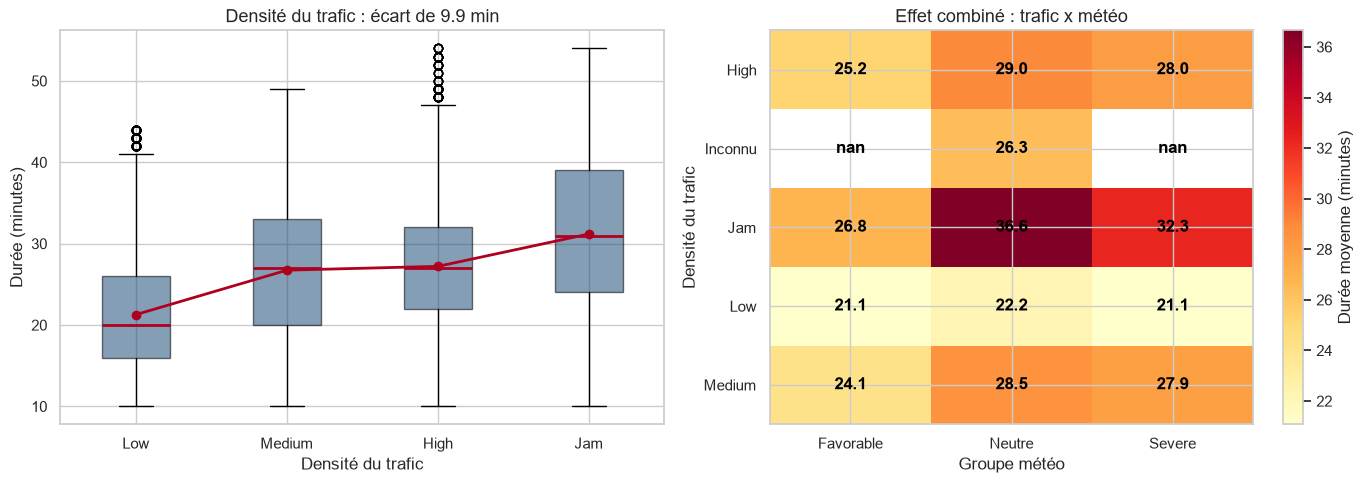

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

niveaux = ["Low", "Medium", "High", "Jam"]
axes[0].boxplot(
    [donnees.loc[donnees["Road_traffic_density"] == n, "duree"] for n in niveaux],
    tick_labels=niveaux,
    patch_artist=True,
    boxprops={"facecolor": "#1f4e79", "alpha": 0.55},
    medianprops={"color": "#b00020", "linewidth": 2},
)
axes[0].plot(
    range(1, 5),
    [par_trafic.loc[n, "duree_moyenne"] for n in niveaux],
    "o-",
    color="#b00020",
    linewidth=2,
)
axes[0].set_title(f"Densité du trafic : écart de {ecart_trafic:.1f} min")
axes[0].set_xlabel("Densité du trafic")
axes[0].set_ylabel("Durée (minutes)")

croise = donnees.pivot_table(
    index="Road_traffic_density",
    columns="meteo_groupe",
    values="duree",
    aggfunc="mean",
    observed=True,
).round(2)
im = axes[1].imshow(croise.to_numpy(dtype=float), cmap="YlOrRd", aspect="auto")
for i in range(croise.shape[0]):
    for j in range(croise.shape[1]):
        valeur = croise.to_numpy(dtype=float)[i, j]
        axes[1].text(
            j,
            i,
            f"{valeur:.1f}",
            ha="center",
            va="center",
            fontweight="bold",
            color="white" if valeur > croise.to_numpy(dtype=float).mean() else "black",
        )
axes[1].set_xticks(range(len(croise.columns)), croise.columns)
axes[1].set_yticks(range(len(croise.index)), croise.index)
axes[1].set_title("Effet combiné : trafic x météo")
axes[1].set_xlabel("Groupe météo")
axes[1].set_ylabel("Densité du trafic")
plt.colorbar(im, ax=axes[1], label="Durée moyenne (minutes)")

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V4_V6_trafic_meteo.png", dpi=110)
plt.show()

In [25]:
# H6 : les deux facteurs se cumulent-ils ?
duree_ref = donnees[
    (donnees["Road_traffic_density"] == "Low")
    & (donnees["meteo_groupe"] == "Favorable")
]["duree"].mean()
duree_trafic = donnees[
    (donnees["Road_traffic_density"].isin(["High", "Jam"]))
    & (donnees["meteo_groupe"] == "Favorable")
]["duree"].mean()
duree_meteo = donnees[
    (donnees["Road_traffic_density"] == "Low") & (donnees["meteo_groupe"] == "Severe")
]["duree"].mean()
duree_cumul = donnees[
    (donnees["Road_traffic_density"].isin(["High", "Jam"]))
    & (donnees["meteo_groupe"] == "Severe")
]["duree"].mean()
duree_prevue = duree_ref + (duree_trafic - duree_ref) + (duree_meteo - duree_ref)

pd.DataFrame(
    [
        {
            "situation": "Fluide + météo favorable (référence)",
            "durée (min)": round(duree_ref, 2),
        },
        {"situation": "Trafic dense seul", "durée (min)": round(duree_trafic, 2)},
        {"situation": "Météo sévère seule", "durée (min)": round(duree_meteo, 2)},
        {"situation": "Les deux ensemble", "durée (min)": round(duree_cumul, 2)},
        {
            "situation": "Si les effets s'additionnaient",
            "durée (min)": round(duree_prevue, 2),
        },
    ]
).set_index("situation")

,durée (min)
situation,
Fluide + météo favorable (référence),21.10
Trafic dense seul,26.37
Météo sévère seule,21.08
Les deux ensemble,31.27
Si les effets s'additionnaient,26.36


## Tâche 8 — Axe Véhicule : efficacité selon la distance

Évaluation de la vitesse relative (min/km) par type de véhicule et croisement par classe de distance.

In [26]:
donnees["minutes_par_km"] = donnees["duree"] / donnees["distance_km"]

par_vehicule = par_categorie("vehicule")
efficacite = (
    donnees.groupby("vehicule", observed=True)
    .agg(nombre=("minutes_par_km", "count"), minutes_par_km=("minutes_par_km", "mean"))
    .round(3)
    .sort_values("minutes_par_km")
)

efficacite

,nombre,minutes_par_km
vehicule,,
electric scooter,3404,3.889
scooter,13878,3.903
bicycle,43,4.073
motorcycle,24197,4.457


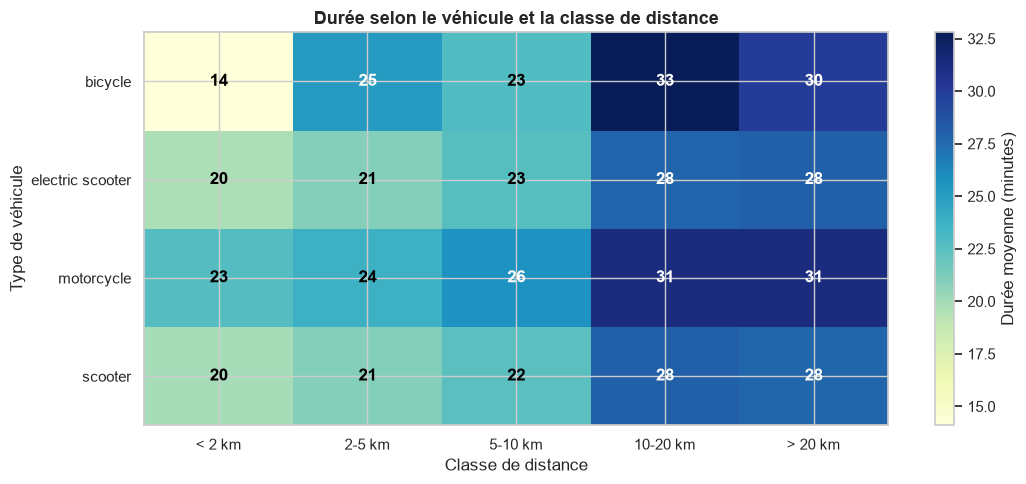

classe_distance,< 2 km,2-5 km,5-10 km,10-20 km,> 20 km
vehicule,,,,,
bicycle,14.1,25.2,22.8,32.8,30.0
electric scooter,19.6,20.9,22.6,27.8,28.0
motorcycle,22.7,23.7,25.7,31.2,31.2
scooter,19.8,20.9,22.5,28.0,27.7


In [27]:
tableau_vehicule = donnees.pivot_table(
    index="vehicule",
    columns="classe_distance",
    values="duree",
    aggfunc="mean",
    observed=True,
).round(1)

# Visualisation V8 - Carte thermique durée selon véhicule et distance
fig, ax = plt.subplots(figsize=(11, 5))
valeurs = tableau_vehicule.to_numpy(dtype=float)
im = ax.imshow(valeurs, cmap="YlGnBu", aspect="auto")

for i in range(valeurs.shape[0]):
    for j in range(valeurs.shape[1]):
        val = valeurs[i, j]
        couleur_texte = "white" if val > valeurs.mean() else "black"
        ax.text(
            j,
            i,
            f"{val:.0f}",
            ha="center",
            va="center",
            fontweight="bold",
            color=couleur_texte,
        )

fig.colorbar(im, ax=ax, label="Durée moyenne (minutes)")
ax.set_xticks(range(len(tableau_vehicule.columns)), tableau_vehicule.columns)
ax.set_yticks(range(len(tableau_vehicule.index)), tableau_vehicule.index)
ax.set_title("Durée selon le véhicule et la classe de distance", fontweight="bold")
ax.set_xlabel("Classe de distance")
ax.set_ylabel("Type de véhicule")
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V8_vehicule_par_distance.png", dpi=110)
plt.show()

tableau_vehicule

## Tâche 9 — Axe Coût : concentration des retards et classement des facteurs

In [28]:
# Agrégation des retards et coûts par condition météo et trafic
concentration = (
    donnees.groupby(["Road_traffic_density", "meteo_groupe"], observed=True)
    .agg(
        nombre=("duree", "count"),
        minutes_perdues_total=("minutes_perdues", "sum"),
        cout_total=("cout_retard", "sum"),
        taux_retard=("en_retard", lambda x: round(100 * x.mean(), 2)),
    )
    .round(2)
)

# Filtrage des groupes représentatifs (effectif >= 100) et tri par temps perdu
concentration_top10 = (
    concentration[concentration["nombre"] >= 100]
    .sort_values("minutes_perdues_total", ascending=False)
    .head(10)
)

concentration_top10

nombre  minutes_perdues_total  cout_total  taux_retard
Road_traffic_density meteo_groupe                                                        
Jam                  Severe          6538                50028.0   1000560.0        72.27
                     Neutre          2152                23464.0    469280.0        87.45
Medium               Severe          5014                21545.0    430900.0        55.80
Jam                  Favorable       4260                18599.0    371980.0        46.13
Medium               Neutre          1681                 9598.0    191960.0        60.50
High                 Severe          2014                 8146.0    162920.0        59.14
Medium               Favorable       3328                 7425.0    148500.0        36.57
Low                  Severe          7181                 6704.0    134080.0        19.66
High                 Favorable       1352                 5135.0    102700.0        39.64
Low                  Favorable       4534                 4387.0     87740.0        20.73

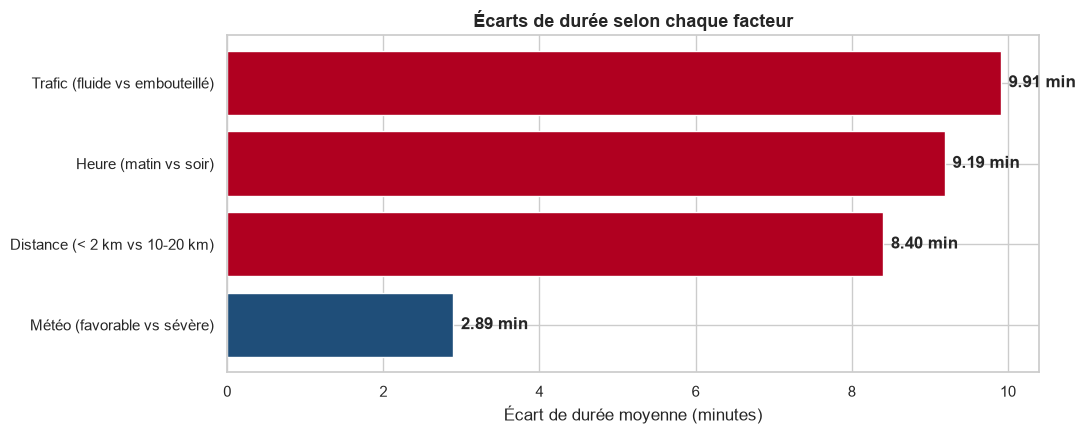

,écart de durée (min)
Météo (favorable vs sévère),2.89
Distance (< 2 km vs 10-20 km),8.40
Heure (matin vs soir),9.19
Trafic (fluide vs embouteillé),9.91


In [29]:
# Écarts de durée moyenne par facteur
ecart_heure = (
    par_tranche.loc["Soir", "duree_moyenne"] - par_tranche.loc["Matin", "duree_moyenne"]
)
ecart_distance = (
    par_distance.loc["10-20 km", "duree_moyenne"]
    - par_distance.loc["< 2 km", "duree_moyenne"]
)

ecarts = pd.Series(
    {
        "Météo (favorable vs sévère)": ecart_meteo,
        "Distance (< 2 km vs 10-20 km)": ecart_distance,
        "Heure (matin vs soir)": ecart_heure,
        "Trafic (fluide vs embouteillé)": ecart_trafic,
    }
).sort_values()

# Visualisation V11 - Synthèse des écarts par facteur
fig, ax = plt.subplots(figsize=(11, 4.5))
valeurs = ecarts.to_numpy()
couleurs = ["#b00020" if v >= 5 else "#1f4e79" for v in valeurs]
barres = ax.barh(ecarts.index, valeurs, color=couleurs)

for barre, valeur in zip(barres, valeurs):
    ax.text(
        valeur + 0.1,
        barre.get_y() + barre.get_height() / 2,
        f"{valeur:.2f} min",
        va="center",
        fontweight="bold",
    )

ax.set_title("Écarts de durée selon chaque facteur", fontweight="bold")
ax.set_xlabel("Écart de durée moyenne (minutes)")
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V11_ecarts_par_facteur.png", dpi=110)
plt.show()

ecarts.round(2).to_frame(name="écart de durée (min)")

---
# Partie C — Synthèse statistique et corrélations (tâches 10 à 12)

## Tâche 10 — Matrice de corrélation

Mesure des associations linéaires. Les modalités `Inconnu` sont exclues pour ne pas biaiser les coefficients.

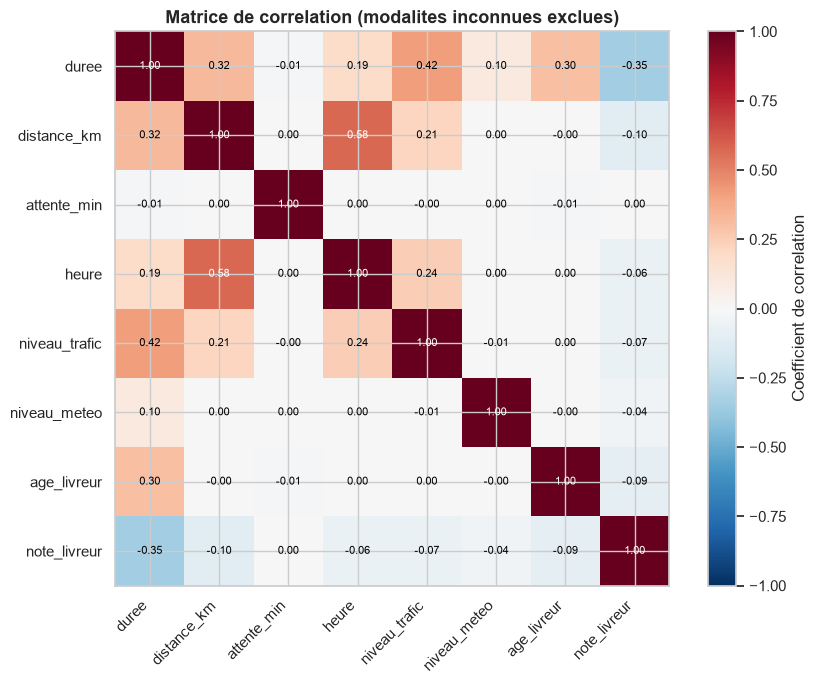

In [30]:
# Exclusion des modalités 'Inconnu' (encodées à 0) pour le calcul de corrélation
donnees_correlation = donnees.copy()
donnees_correlation[["niveau_trafic", "niveau_meteo"]] = donnees_correlation[
    ["niveau_trafic", "niveau_meteo"]
].replace(0, np.nan)

variables = [
    "duree",
    "distance_km",
    "attente_min",
    "heure",
    "niveau_trafic",
    "niveau_meteo",
    "age_livreur",
    "note_livreur",
]
matrice = donnees_correlation[variables].corr()

# Effectifs effectivement utilises pour les deux correlations sensibles
modalites_ignorees = pd.DataFrame(
    [
        {
            "variable": nom,
            "lignes ignorees": int(donnees_correlation[nom].isna().sum()),
            "lignes utilisees": int(donnees_correlation[nom].notna().sum()),
        }
        for nom in ["niveau_trafic", "niveau_meteo"]
    ]
)
modalites_ignorees

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matrice.to_numpy(dtype=float), cmap="RdBu_r", vmin=-1, vmax=1)
for i in range(len(variables)):
    for j in range(len(variables)):
        valeur = matrice.to_numpy(dtype=float)[i, j]
        ax.text(
            j,
            i,
            f"{valeur:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(valeur) > 0.45 else "black",
        )
ax.set_xticks(range(len(variables)), variables, rotation=45, ha="right")
ax.set_yticks(range(len(variables)), variables)
ax.set_title("Matrice de correlation (modalites inconnues exclues)", fontweight="bold")
plt.colorbar(im, ax=ax, label="Coefficient de correlation")
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V10_matrice_correlation.png", dpi=110)
plt.show()

## Tâche 11 — Tests statistiques et intervalles de confiance

- Vérification des effectifs par groupe (KPI K12, seuil >= 100).
- Estimation de l'écart trafic par ré-échantillonnage Bootstrap (1 000 itérations, IC 95%).
- Distinction entre significativité statistique et utilité opérationnelle.

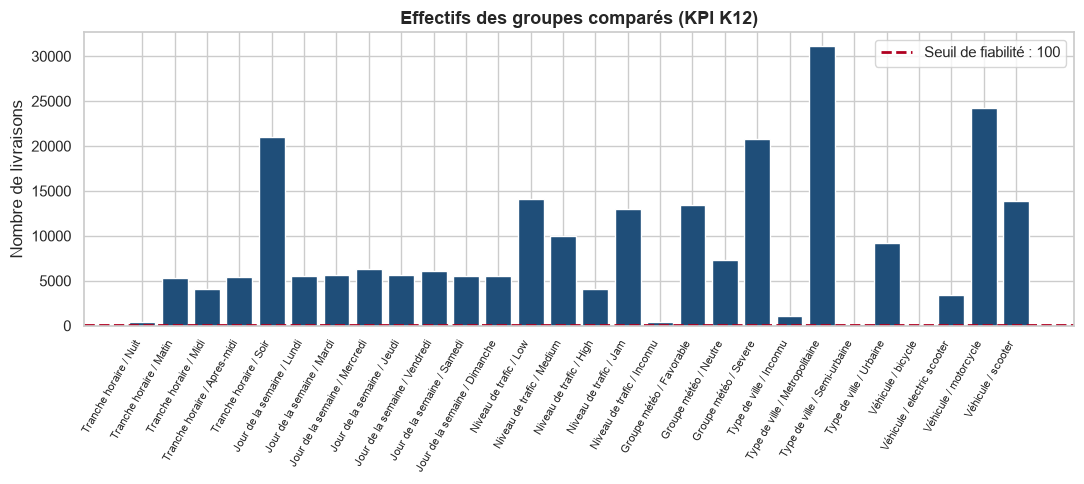

,comparaison,modalité,effectif,conclusion possible
24,Véhicule,bicycle,43,NON


In [31]:
# Contrôle des effectifs minimaux par groupe (KPI K12, seuil >= 100)
groupes = {
    "Tranche horaire": par_tranche["nombre"],
    "Jour de la semaine": par_jour["nombre"],
    "Niveau de trafic": par_trafic["nombre"],
    "Groupe météo": par_meteo["nombre"],
    "Type de ville": par_ville["nombre"],
    "Véhicule": par_vehicule["nombre"],
}

kpi_k12 = pd.DataFrame(
    [
        {
            "comparaison": nom,
            "modalité": modalite,
            "effectif": int(effectif),
            "conclusion possible": "oui" if effectif >= SEUIL_MIN_LIVRAISONS else "NON",
        }
        for nom, serie in groupes.items()
        for modalite, effectif in serie.items()
    ]
)

# Visualisation V12 - Effectifs des groupes et seuil de représentativité
fig, ax = plt.subplots(figsize=(11, 5))
petits = kpi_k12[~kpi_k12["conclusion possible"].eq("oui")]
couleurs = [
    "#1f4e79" if v else "#b00020" for v in kpi_k12["conclusion possible"].eq("oui")
]

ax.bar(range(len(kpi_k12)), kpi_k12["effectif"], color=couleurs)
ax.axhline(
    SEUIL_MIN_LIVRAISONS,
    color="#b00020",
    linestyle="--",
    linewidth=2,
    label=f"Seuil de fiabilité : {SEUIL_MIN_LIVRAISONS}",
)
etiquettes = [f"{c} / {m}" for c, m in zip(kpi_k12["comparaison"], kpi_k12["modalité"])]
ax.set_xticks(range(len(kpi_k12)), etiquettes, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Nombre de livraisons")
ax.set_title("Effectifs des groupes comparés (KPI K12)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V12_effectifs_groupes.png", dpi=110)
plt.show()

kpi_k12[~kpi_k12["conclusion possible"].eq("oui")]

In [32]:
# Intervalle de confiance 95% par ré-échantillonnage Bootstrap (1 000 itérations)
aleatoire = np.random.default_rng(1)
ecarts_trafic = [
    aleatoire.choice(bouche.values, len(bouche)).mean()
    - aleatoire.choice(bas.values, len(bas)).mean()
    for _ in range(1000)
]
intervalle = np.percentile(ecarts_trafic, [2.5, 97.5])

correlation_attente = donnees["attente_min"].corr(donnees["duree"])

pd.DataFrame(
    [
        {
            "mesure": "Écart trafic (fluide vs embouteillé)",
            "effet estimé": f"{ecart_trafic:.2f} min",
            "intervalle 95%": f"[{intervalle[0]:.2f} ; {intervalle[1]:.2f}]",
            "exploitable": "oui",
        },
        {
            "mesure": "Écart météo (favorable vs sévère)",
            "effet estimé": f"{ecart_meteo:.2f} min",
            "intervalle 95%": "—",
            "exploitable": "oui",
        },
        {
            "mesure": "Corrélation temps d'attente / durée",
            "effet estimé": f"{correlation_attente:.3f}",
            "intervalle 95%": "—",
            "exploitable": "NON (effet négligeable)",
        },
    ]
).set_index("mesure")

,effet estimé,intervalle 95%,exploitable
mesure,,,
Écart trafic (fluide vs embouteillé),9.91 min,[9.71 ; 10.12],oui
Écart météo (favorable vs sévère),2.89 min,—,oui
Corrélation temps d'attente / durée,-0.010,—,NON (effet négligeable)


## Tâche 12 — Tableau de bord des 12 KPI clés

In [33]:
# Les 12 KPI du cahier des charges, plus deux statistiques complementaires.
# Chaque KPI porte son code pour que le tableau et le cahier des charges
# puissent etre compares ligne a ligne.

# K10 : gain unitaire si les livraisons en congestion etaient deplacees.
# Mesure a classe de distance comparable, comme les autres leviers.
ref_fluide = (
    donnees[donnees["Road_traffic_density"] == "Low"]
    .groupby("classe_distance", observed=True)["duree"]
    .mean()
)
lignes_jam = donnees["Road_traffic_density"] == "Jam"
gain_bouchons = (
    donnees.loc[lignes_jam, "duree"].astype(float)
    - donnees.loc[lignes_jam, "classe_distance"].map(ref_fluide).astype(float)
).mean()

indicateurs = pd.DataFrame(
    [
        ("Délais", "K1", "Durée médiane", f"{donnees['duree'].median():.1f}", "min"),
        ("Délais", "-", "Durée moyenne (complémentaire)", f"{donnees['duree'].mean():.1f}", "min"),
        (
            "Délais",
            "K6",
            "Écart pire / meilleur créneau",
            f"{par_tranche['duree_moyenne'].max() - par_tranche['duree_moyenne'].min():.1f}",
            "min",
        ),
        (
            "Délais",
            "K3",
            "Minutes perdues par livraison",
            f"{donnees['minutes_perdues'].mean():.2f}",
            "min",
        ),
        (
            "Délais",
            "K5",
            "Temps d'attente moyen",
            f"{donnees['attente_min'].mean():.1f}",
            "min",
        ),
        ("Retards", "K2", "Taux de retard", f"{100 * donnees['en_retard'].mean():.1f}", "%"),
        (
            "Retards",
            "K4",
            "Temps perdu sur la période",
            f"{minutes_total / 1440:,.0f}",
            "jours",
        ),
        (
            "Retards",
            "K10",
            "Gain unitaire sans les bouchons",
            f"{gain_bouchons:.2f}",
            "min",
        ),
        ("Conditions", "K7", "Trafic dense vs fluide", f"{ecart_trafic:.1f}", "min"),
        ("Conditions", "K8", "Météo sévère vs favorable", f"{ecart_meteo:.1f}", "min"),
        ("Espace", "K9", "Minutes ajoutées par km", f"{pente:.2f}", "min/km"),
        (
            "Espace",
            "-",
            "Corrélation distance / durée (complémentaire)",
            f"{correlation_distance:.2f}",
            "coef.",
        ),
        ("Qualité", "K11", "Conservation des données", f"{taux_conservation:.1f}", "%"),
        ("Qualité", "K12", "Groupes non concluants", f"{len(petits)}", "groupes"),
    ],
    columns=["Catégorie", "Code", "Indicateur", "Valeur", "Unité"],
)

indicateurs

,Catégorie,Code,Indicateur,Valeur,Unité
0,Délais,K1,Durée médiane,26.0,min
1,Délais,-,Durée moyenne (complémentaire),26.3,min
2,Délais,K6,Écart pire / meilleur créneau,9.2,min
3,Délais,K3,Minutes perdues par livraison,3.94,min
4,Délais,K5,Temps d'attente moyen,10.0,min
5,Retards,K2,Taux de retard,45.6,%
6,Retards,K4,Temps perdu sur la période,114,jours
7,Retards,K10,Gain unitaire sans les bouchons,8.78,min
8,Conditions,K7,Trafic dense vs fluide,9.9,min
9,Conditions,K8,Météo sévère vs favorable,2.9,min


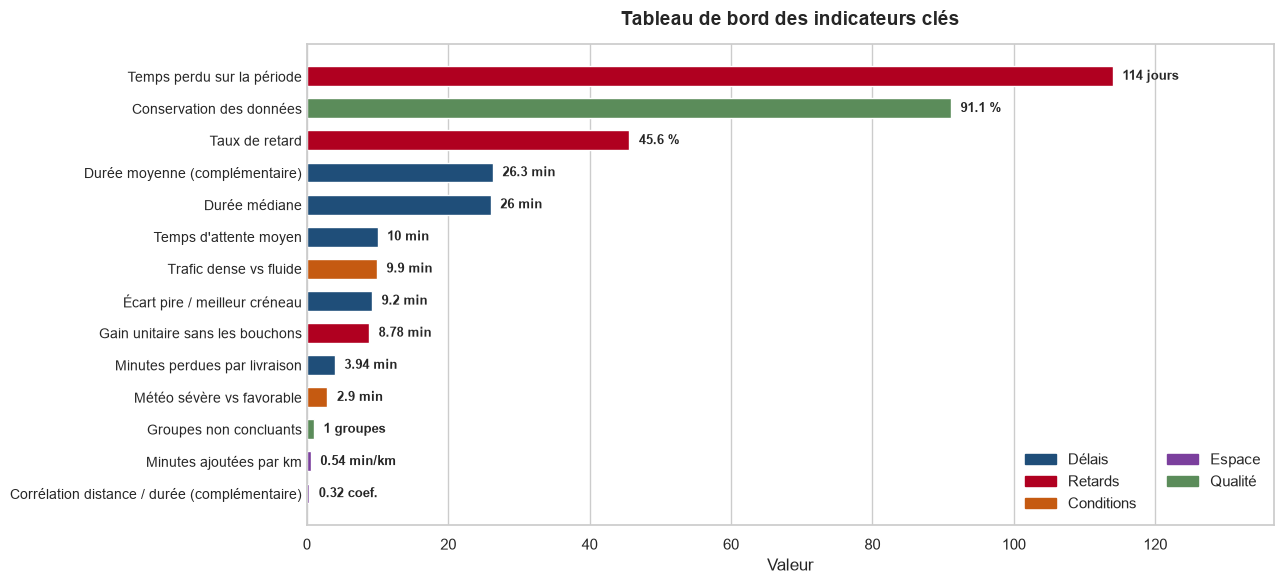

In [34]:
# Même contenu sous forme graphique. Les barres sont ordonnées par valeur et
# colorées par catégorie : la longueur rend immédiatement compte de l'ampleur
# de chaque indicateur.
couleurs_cat = {
    "Délais": "#1f4e79",
    "Retards": "#b00020",
    "Conditions": "#c55a11",
    "Espace": "#7b3f9d",
    "Qualité": "#5b8c5a",
}

vue = indicateurs.assign(
    valeur_num=indicateurs["Valeur"].str.replace(",", ".", regex=False).astype(float)
).sort_values("valeur_num")

fig, ax = plt.subplots(figsize=(13, 6))
barres = ax.barh(
    vue["Indicateur"],
    vue["valeur_num"],
    color=[couleurs_cat[c] for c in vue["Catégorie"]],
    height=0.62,
)
for barre, valeur, unite in zip(barres, vue["valeur_num"], vue["Unité"]):
    ax.text(
        valeur + vue["valeur_num"].max() * 0.012,
        barre.get_y() + barre.get_height() / 2,
        f"{valeur:g} {unite}",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Tableau de bord des indicateurs clés", fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Valeur")
ax.set_xlim(0, vue["valeur_num"].max() * 1.2)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0, labelsize=10)

legende = [plt.Rectangle((0, 0), 1, 1, color=color) for color in couleurs_cat.values()]
ax.legend(legende, list(couleurs_cat), loc="lower right", frameon=False, ncol=2)

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V13_tableau_de_bord_kpi.png", dpi=110)
plt.show()

---
# Partie D — Scénarios et recommandations opérationnelles (tâches 13 à 16)

## Tâche 13 — Chiffrage des scénarios d'action

Estimation des gains en minutes en appliquant les performances observées en conditions de référence, à distance comparable.

> **Ces leviers ne sont pas cumulables.** Ils se recouvrent : une livraison en congestion peut aussi être concernée par la météo ou par l'heure. Additionner les lignes compterait les mêmes livraisons plusieurs fois. Le total réaliste, retenu une seule fois par livraison, est calculé à la tâche 14.

In [35]:
# Un levier donne un gain a certaines livraisons seulement. Le gain est mesure
# a classe de distance comparable : chaque livraison est comparee a la duree
# moyenne de SA classe dans la situation de reference. Les livraisons que le
# levier ne concerne pas recoivent NaN.

def gain_par_livraison(masque, reference):
    reference_par_classe = (
        donnees[reference].groupby("classe_distance", observed=True)["duree"].mean()
    )
    ligne_reference = donnees["classe_distance"].map(reference_par_classe).astype(float)
    return (donnees["duree"].astype(float) - ligne_reference).where(masque)


# Masques boolens de filtrage
masque_jam = donnees["Road_traffic_density"] == "Jam"
masque_faible = donnees["Road_traffic_density"] == "Low"
masque_pointe = donnees["est_pointe"]
masque_severe = donnees["meteo_groupe"] == "Severe"
masque_favorable = donnees["meteo_groupe"] == "Favorable"

# Gain potentiel par optimisation du vehicule par classe de distance
durees_par_vehicule = donnees.pivot_table(
    index="vehicule",
    columns="classe_distance",
    values="duree",
    aggfunc="mean",
    observed=True,
)
meilleure_duree = (
    donnees["classe_distance"].map(durees_par_vehicule.min().astype(float)).astype(float)
)

# Une colonne par levier : le gain de chaque livraison, pour chaque levier.
# NaN signifie que le levier ne concerne pas cette livraison.
gains = pd.DataFrame(
    {
        "Planifier hors des zones congestionnées": gain_par_livraison(masque_jam, masque_faible),
        "Prévoir une marge par mauvais temps": gain_par_livraison(
            masque_severe, masque_favorable
        ),
        "Décaler les livraisons hors des pointes": gain_par_livraison(
            masque_pointe, ~masque_pointe
        ),
        "Adapter le véhicule au type de trajet": (
            donnees["duree"].astype(float) - meilleure_duree
        ),
    },
    index=donnees.index,
)

# Texte de chaque levier : hypothese de lecture et limite.
LEVIERS = {
    "Planifier hors des zones congestionnées": (
        "À distance comparable, un trajet en trafic fluide dure moins longtemps.",
        "Le report modal n'est pas vérifiable ici.",
    ),
    "Prévoir une marge par mauvais temps": (
        "À distance comparable, la météo sévère allonge la durée.",
        "La météo n'est pas contrôlable : le levier est l'anticipation, "
        "qui ne supprime pas le retard mais le déplace chez le client.",
    ),
    "Décaler les livraisons hors des pointes": (
        "À distance comparable, une livraison hors pointe dure moins longtemps.",
        "Le client choisit son heure de commande.",
    ),
    "Adapter le véhicule au type de trajet": (
        "Meilleur véhicule par classe de distance, à distance comparable.",
        "Le coût d'acquisition n'est pas mesuré.",
    ),
}

scenarios = pd.DataFrame(
    [
        {
            "scenario": nom,
            "livraisons concernées": int(gains[nom].notna().sum()),
            "durée actuelle (min)": round(
                donnees.loc[gains[nom].notna(), "duree"].mean(), 2
            ),
            "gain / livraison (min)": round(gains[nom].mean(), 2),
            "gain total (min)": round(gains[nom].sum()),
            # Les leviers se recouvrent : additionner les lignes compterait
            # plusieurs fois les memes livraisons.
            "cumulable": "non",
            "hypothèse": LEVIERS[nom][0],
            "limite": LEVIERS[nom][1],
        }
        for nom in gains.columns
    ]
).sort_values("gain total (min)", ascending=False)

scenarios[
    [
        "scenario",
        "livraisons concernées",
        "durée actuelle (min)",
        "gain / livraison (min)",
        "gain total (min)",
        "cumulable",
    ]
]

,scenario,livraisons concernées,durée actuelle (min),gain / livraison (min),gain total (min),cumulable
0,Planifier hors des zones congestionnées,12950,31.19,8.78,113641,non
3,Adapter le véhicule au type de trajet,41522,26.32,2.39,99173,non
1,Prévoir une marge par mauvais temps,20747,26.93,2.88,59733,non
2,Décaler les livraisons hors des pointes,15966,27.58,1.88,29994,non


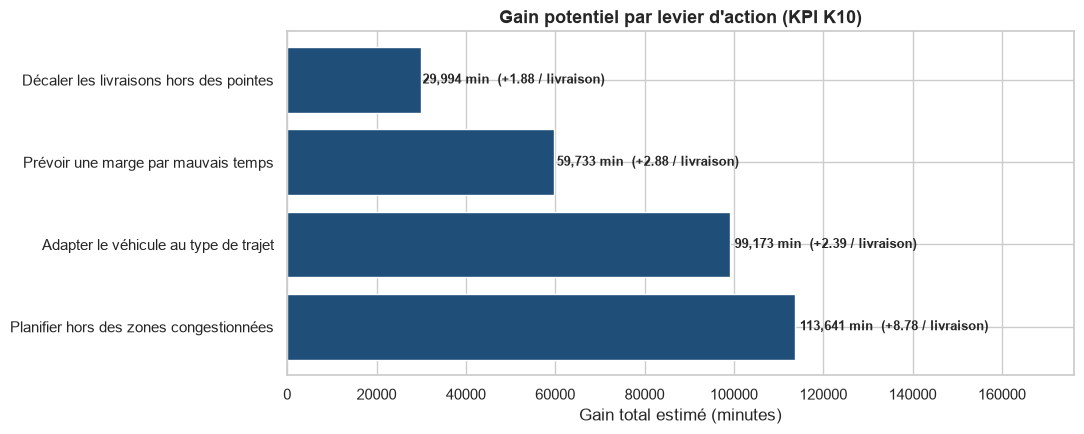

scenario,Planifier hors des zones congestionnées,Adapter le véhicule au type de trajet,Prévoir une marge par mauvais temps,Décaler les livraisons hors des pointes
hypothèse,"À distance comparable, un trajet en trafic flu...","Meilleur véhicule par classe de distance, à di...","À distance comparable, la météo sévère allonge...","À distance comparable, une livraison hors poin..."
limite,Le report modal n'est pas vérifiable ici.,Le coût d'acquisition n'est pas mesuré.,La météo n'est pas contrôlable : le levier est...,Le client choisit son heure de commande.


In [36]:
plt.figure(figsize=(11, 4.5))
barres = plt.barh(scenarios["scenario"], scenarios["gain total (min)"], color="#1f4e79")
for barre, valeur, unite in zip(
    barres, scenarios["gain total (min)"], scenarios["gain / livraison (min)"]
):
    plt.text(
        valeur * 1.01,
        barre.get_y() + barre.get_height() / 2,
        f"{valeur:,.0f} min  ({unite:+.2f} / livraison)",
        va="center",
        fontsize=9,
        fontweight="bold",
    )
plt.xlabel("Gain total estimé (minutes)")
plt.title("Gain potentiel par levier d'action (KPI K10)", fontweight="bold")
plt.xlim(0, scenarios["gain total (min)"].max() * 1.55)
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V14_gains_par_scenario.png", dpi=110)
plt.show()

scenarios.set_index("scenario")[["hypothèse", "limite"]].T

## Tâche 14 — Limites et cadre d'interprétation

- **Corrélation vs Causalité :** données observationnelles sans intervention contrôlée (facteurs de confusion identifiés : attribution préférentielle des tournées difficiles aux livreurs expérimentés).
- **Distance à vol d'oiseau :** sous-estimation structurelle de la distance routière réelle.
- **Périmètre temporel :** 8 semaines de données (pas d'effet saisonnier annuel).
- **Hypothèses économiques :** coût horaire conventionnel sans données comptables directes.

## Tâche 15 — Validation formelle des 6 hypothèses de travail

In [37]:
def formater_p(p):
    """Ecrit une p-value lisible.

    Sous 1e-300 la notation scientifique affiche 0,000e+00 : le resultat est
    si petit qu'il ne peut plus s'ecrire, on affiche donc une borne.
    """
    if p < 1e-300:
        return "< 1e-300"
    return f"= {p:.1e}"


# ecart_heure et ecart_distance sont déjà calculés en amont (figure V11) :
# seules les variables propres à cette cellule sont définies ici.
ecart_pointe = pointe.mean() - autres.mean()

hypotheses = pd.DataFrame(
    [
        (
            "H1",
            "La durée augmente avec la distance",
            f"corrélation {correlation_distance:.2f} ; {pente:.2f} min/km",
            "confirmée",
            "modéré",
        ),
        (
            "H2",
            "Le trafic dense allonge les délais",
            f"écart {ecart_trafic:.1f} min ; p {formater_p(p_trafic)}",
            "confirmée",
            "fort",
        ),
        (
            "H3",
            "Les pointes concentrent les retards",
            f"écart {ecart_pointe:.1f} min ; p {formater_p(test_pointe.pvalue)}",
            "confirmée",
            "modéré",
        ),
        (
            "H4",
            "L'efficacité du véhicule dépend du contexte",
            "le plus rapide change selon la classe de distance",
            "confirmée",
            "arbitrage",
        ),
        (
            "H5",
            "L'attente allonge la durée totale",
            f"corrélation {correlation_attente:.3f}",
            "infirmée",
            "négligeable (r ≈ 0)",
        ),
        (
            "H6",
            "Les effets du trafic et de la météo se cumulent",
            f"écart à l'additivité {duree_cumul - duree_prevue:+.1f} min",
            "confirmée",
            "super-additif",
        ),
    ],
    columns=["N°", "énoncé", "mesure", "statut", "portée"],
)

hypotheses

,N°,énoncé,mesure,statut,portée
0,H1,La durée augmente avec la distance,corrélation 0.32 ; 0.54 min/km,confirmée,modéré
1,H2,Le trafic dense allonge les délais,écart 9.9 min ; p < 1e-300,confirmée,fort
2,H3,Les pointes concentrent les retards,écart 2.1 min ; p = 4.2e-91,confirmée,modéré
3,H4,L'efficacité du véhicule dépend du contexte,le plus rapide change selon la classe de distance,confirmée,arbitrage
4,H5,L'attente allonge la durée totale,corrélation -0.010,infirmée,négligeable (r ≈ 0)
5,H6,Les effets du trafic et de la météo se cumulent,écart à l'additivité +4.9 min,confirmée,super-additif


## Tâche 16 — Synthèse décisionnelle et priorités d'action

### Conclusion

1. **Trafic (+9,9 min) et créneau horaire (+9,2 min le soir) :** principaux leviers d'allongement des délais.
2. **Cumul super-additif :** l'interaction trafic dense + météo sévère amplifie le retard au-delà de la somme des effets séparés (+4,9 min d'amplification).
3. **Temps de préparation en cuisine :** corrélation nulle (r = -0,010), aucun impact sur la durée de livraison.
4. **Véhicules :** le deux-roues léger (trottinette/vélo) surclasse la moto sur < 5 km ; la moto redevient optimale au-delà.

### Recommandations opérationnelles

In [38]:
recommandations = pd.DataFrame(
    {
        "Priorité": range(1, len(scenarios) + 1),
        "Action": scenarios["scenario"],
        "Gain estimé": [
            f"{g:+.2f} min / livraison" for g in scenarios["gain / livraison (min)"]
        ],
        "Gain du levier": [
            f"{g:,.0f} min".replace(",", " ") for g in scenarios["gain total (min)"]
        ],
        "Cumulable": scenarios["cumulable"],
        "Limite": scenarios["limite"],
    }
).set_index("Priorité")
recommandations

,Action,Gain estimé,Gain du levier,Cumulable,Limite
Priorité,,,,,
1,Planifier hors des zones congestionnées,+8.78 min / livraison,113 641 min,non,Le report modal n'est pas vérifiable ici.
2,Adapter le véhicule au type de trajet,+2.39 min / livraison,99 173 min,non,Le coût d'acquisition n'est pas mesuré.
3,Prévoir une marge par mauvais temps,+2.88 min / livraison,59 733 min,non,La météo n'est pas contrôlable : le levier est...
4,Décaler les livraisons hors des pointes,+1.88 min / livraison,29 994 min,non,Le client choisit son heure de commande.


In [39]:
# Les leviers se recouvrent. Une livraison peut être concernée par plusieurs
# (par exemple en congestion ET par mauvais temps). Additionner les gains
# compterait donc plusieurs fois les mêmes livraisons.
# Le total réaliste retient, pour chaque livraison, le MEILLEUR gain parmi les
# leviers qui la concernent.
meilleur_gain = gains.max(axis=1, skipna=True).fillna(0).clip(lower=0)
concernees = gains.notna().any(axis=1)

# Attention : ce total et celui du KPI K4 ne mesurent pas la meme chose.
# K4 additionne l'EXCES au seuil de retard, uniquement sur les retards.
# Un gain de scenario reduit la duree totale, y compris sur des livraisons
# qui étaient deja dans les temps. Les deux chiffres ne sont pas comparables.
controle_cumul = pd.DataFrame(
    {
        "somme naïve des leviers (min, invalide)": [
            round(scenarios["gain total (min)"].sum())
        ],
        "total non cumulable (min)": [round(meilleur_gain.sum())],
        "gain moyen sur les livraisons concernées (min)": [
            round(meilleur_gain[concernees].mean(), 2)
        ],
        "livraisons distinctes concernées": [int(concernees.sum())],
        "temps total perdu sur la période (min)": [round(minutes_total)],
    }
)
controle_cumul

# Le Markdown exporté doit porter l'avertissement : sans lui, le lecteur ne voit
# qu'une liste de nombres qui s'additionnent et conclut à une économie
# supérieure au retard total, ce qui est impossible.
total_realiste = f"{meilleur_gain.sum():,.0f}".replace(",", " ")
total_naif = f"{scenarios['gain total (min)'].sum():,.0f}".replace(",", " ")

contenu = recommandations.reset_index().to_markdown(index=False)
contenu += (
    "\n\n**Ces leviers ne sont pas cumulables.** Ils se recouvrent : additionner "
    "leurs gains compterait plusieurs fois les mêmes livraisons. Le total "
    f"réaliste, retenu une seule fois par livraison, est de **{total_realiste} min** "
    f"(contre {total_naif} min si on les additionne à la main).\n"
)

(DOSSIER_TABLES / "recommandations.md").write_text(contenu, encoding="utf-8")

1711

> **Levier à exclure :** Réduction du temps de préparation en cuisine. Avec une corrélation nulle (r = -0,010), accélérer la cuisine ne produit aucun gain sur le délai global de livraison.

---

## Sources

| Information | Valeur
|---|---
| Jeu de données | Food Delivery Dataset
| Éditeur | gauravmalik26
| Lien | <https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset>
| Fichier | `train.csv` — 45 593 lignes, 20 colonnes
| Période | février → avril 2022

In [40]:
# Export des résultats et vérification finale
# Les codes K1 a K12 sont les KPI demandes ; les lignes sans code sont des
# statistiques de confort, qui ne comptent pas dans le total.
nb_kpi = int(indicateurs["Code"].str.fullmatch(r"K\d+").sum())
indicateurs.to_csv(DOSSIER_TABLES / "kpi.csv", index=False, encoding="utf-8")
scenarios.to_csv(DOSSIER_TABLES / "scenarios.csv", index=False, encoding="utf-8")
hypotheses.to_csv(DOSSIER_TABLES / "hypotheses.csv", index=False, encoding="utf-8")
kpi_k12.to_csv(DOSSIER_TABLES / "effectifs_groupes.csv", index=False, encoding="utf-8")

pd.DataFrame(
    [
        ["Lignes analysées", f"{len(donnees):,}"],
        ["Taux de conservation", f"{taux_conservation:.2f} %"],
        ["Seuil de retard", f"{SEUIL_RETARD:.1f} min"],
        ["KPI du cahier des charges", nb_kpi],
        ["Statistiques complémentaires", len(indicateurs) - nb_kpi],
        ["Hypothèses testées", len(hypotheses)],
        ["Scénarios chiffrés", len(scenarios)],
        ["Figures produites", len(list(DOSSIER_FIGURES.glob("*.png")))],
        ["Tableaux exportés", len(list(DOSSIER_TABLES.glob("*.csv")))],
    ],
    columns=["élément", "valeur"],
).set_index("élément")

,valeur
élément,
Lignes analysées,"41,522"
Taux de conservation,91.07 %
Seuil de retard,26.0 min
KPI du cahier des charges,12
Statistiques complémentaires,2
Hypothèses testées,6
Scénarios chiffrés,4
Figures produites,10
Tableaux exportés,4
